In [2]:
import pandas as pd
import numpy as np

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
class MixedNaiveBayes:
    def __init__(self, data, X, Y, alpha=1.5):
        self.data = data
        self.X = X
        self.Y = Y
        self.alpha = alpha
        self.classes = data[Y].unique()

    def detect_feature_types(self):
        types = {}
        for feature in self.X:
            nunique = self.data[feature].nunique()

            if nunique == 2:
                types[feature] = "binary"
            elif nunique <= 20:
                types[feature] = "categorical"
            else:
                types[feature] = "continuous"

        return types

    def compute_priors(self):
        priors = {}
        total = len(self.data)

        for c in self.classes:
            priors[c] = (self.data[self.data[self.Y] == c].shape[0]) / total

        return priors

    def fit(self):
        self.feature_types = self.detect_feature_types()
        self.priors = self.compute_priors()

        self.cond_probs = {}
        self.gaussians = {}
        self.category_values = {}

        # Store all possible values for discrete features
        for feature in self.X:
            ftype = self.feature_types[feature]
            if ftype in ("binary", "categorical"):
                self.category_values[feature] = self.data[feature].unique().tolist()

        for c in self.classes:
            subset = self.data[self.data[self.Y] == c]

            self.cond_probs[c] = {}
            self.gaussians[c] = {}

            for feature in self.X:
                ftype = self.feature_types[feature]

                if ftype in ("binary", "categorical"):
                    values = self.category_values[feature]
                    counts = subset[feature].value_counts().to_dict()

                    total_count = len(subset)
                    K = len(values)
                    alpha = self.alpha
                    # add laplace smoothing to prevent zero conditional probability:
                    self.cond_probs[c][feature] = {
                        v: (counts.get(v, 0) + alpha) / (total_count + alpha * K)
                        for v in values
                    }

                elif ftype == "continuous":
                    mu = subset[feature].mean()
                    var = subset[feature].var(ddof=0) + 1e-9
                    self.gaussians[c][feature] = (mu, var)

    def gaussian_prob(self, x, mu, var):
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mu) ** 2) / (2 * var))

    def predict_row(self, row):
        class_scores = {}

        for c in self.classes:
            score = np.log(self.priors[c] + 1e-12)

            for feature in self.X:
                ftype = self.feature_types[feature]
                value = row[feature]

                if ftype in ("binary", "categorical"):
                    prob = self.cond_probs[c][feature].get(value)

                    # If something weird slips through
                    if prob is None:
                        K = len(self.category_values[feature])
                        prob = 1.0 / max(1, K)

                    score += np.log(prob + 1e-12)

                else:  # continuous
                    mu, var = self.gaussians[c][feature]
                    score += np.log(self.gaussian_prob(value, mu, var) + 1e-12)

            class_scores[c] = score

        return max(class_scores, key=class_scores.get)

    def predict(self, X_df):
        return [self.predict_row(row) for _, row in X_df.iterrows()]


Voting Dataset

In [ ]:
df_binary = pd.read_csv("binary.csv")

In [41]:
df_voting = pd.read_csv("voting.csv")
df_voting.describe()

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
count,435,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


In [ ]:
n_init = len(df_voting)
# drop NAN values
df_voting = df_voting.dropna()

n_final = len(df_voting)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")


enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_voting = enc.fit_transform(df_voting['label'].to_numpy())


# replace y and n with 1 and 0
mapping = {'y': 1, 'n': 0, 'Y': 1, 'N': 0}
df_voting.replace(mapping, inplace=True)

voting_train, voting_test = train_test_split(df_voting, test_size=0.8, random_state=42)


Initial number of rows: 435
Number of rows dropped: 203
Final number of rows: 232


/var/folders/py/701t8p_s2fv4q44kh8y0yqc40000gn/T/ipykernel_99604/2134301255.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_voting.replace(mapping, inplace=True)


In [44]:
def evaluate_NB(model_class, train_df, test_df, label_col, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Initialize model
    model = model_class(train_df, feature_cols, label_col)
    
    # Train
    model.fit()

    # Predict
    X_test = test_df.drop(label_col, axis=1)
    y_pred = model.predict(X_test)

    # Evaluate
    y_true = test_df[label_col]
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1, y_pred

acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    voting_train,
    voting_test,
    label_col='label'
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)


NBC Accuracy: 0.9193548387096774
NBC F1 Score: 0.9193338537600833


In [45]:
def evaluate_LR(train_df, test_df, label_col, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Split features + labels
    X_train = train_df[feature_cols]
    y_train = train_df[label_col]

    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    # Train LR
    clf = LogisticRegression(penalty=None).fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return acc, f1, y_pred


In [46]:
acc, f1, y_preds = evaluate_LR(
    voting_train,
    voting_test,
    label_col='label'
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)

NBC Accuracy: 0.9301075268817204
NBC F1 Score: 0.9293705272382066


In [11]:
from sklearn.naive_bayes import CategoricalNB

def evaluate_NB(train_df, test_df, label_col, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Split features + labels
    X_train = train_df[feature_cols]
    y_train = train_df[label_col]

    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    # Train LR
    clf = CategoricalNB().fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return acc, f1, y_pred

In [ ]:

def run_learning_curve_experiment(
    data,
    y_lable,
    m_values=None, 
    runs_per_m=500,
    model_nb_class=MixedNaiveBayes
):
    # If no m-values provided: use 10%, 20%, ..., 90% of data size
    N = len(data)
    if m_values is None:
        m_values =  np.linspace(0.02, 0.5, 20)

    results_nbc = []
    results_lr = []
    X = data.loc[:,data.columns.drop(y_lable)]
    y = data.loc[:,y_lable]

    for m in m_values:
        nbc_scores = []
        lr_scores = []
        sss = StratifiedShuffleSplit(
        n_splits=runs_per_m,
        train_size=m,
        random_state=52
            )

        for train_idx, test_idx in sss.split(X, y):

       
            X_train = X.iloc[train_idx]
            y_train = y.iloc[train_idx]

            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            # Create train and test dataframes for NB
            train_df = pd.concat([X_train, y_train], axis=1)
            test_df = pd.concat([X_test, y_test], axis=1)

            # --- NBC ---
            acc_nb, f1_nb, _ = evaluate_NB(
                model_nb_class,
                train_df,
                test_df,
                label_col=y.name
            )
            nbc_scores.append([acc_nb, f1_nb])

            # --- Logistic Regression ---
            acc_nb, f1_nb, _ = evaluate_LR(train_df, test_df, y_lable)
            lr_scores.append([acc_nb, f1_nb])

        # Average over the 1000 runs
        results_nbc.append(np.mean(nbc_scores, axis=0))
        results_lr.append(np.mean(lr_scores, axis=0))

    return np.array(results_nbc), np.array(results_lr), m_values*len(df_voting)

In [48]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    df_voting,
    'label',
    runs_per_m=1000
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)


NBC:
 [[0.84697391 0.84555326]
 [0.88580617 0.88554047]
 [0.893      0.8928283 ]
 [0.89448416 0.89430387]
 [0.89692661 0.89673493]
 [0.89775349 0.89757017]
 [0.89929858 0.89909842]
 [0.89947115 0.89929095]
 [0.90047805 0.90027272]
 [0.90031683 0.90011856]
 [0.90142714 0.90126134]
 [0.90134694 0.90113543]
 [0.90187565 0.90169798]
 [0.90278947 0.90257915]
 [0.90307527 0.90291336]
 [0.90317486 0.90297158]
 [0.90413333 0.90395324]
 [0.90436723 0.90416698]
 [0.90485632 0.90466459]
 [0.9050117  0.90486284]
 [0.90480357 0.90459037]
 [0.90513333 0.90495669]
 [0.90490123 0.90467096]
 [0.90674684 0.90659633]
 [0.90684516 0.90665001]
 [0.90679605 0.9066328 ]
 [0.90585235 0.90563259]
 [0.90703425 0.9068606 ]
 [0.90751049 0.90735097]
 [0.90849286 0.90830061]]
LR:
 [[0.84450435 0.84276984]
 [0.87937004 0.87824551]
 [0.89170089 0.89110812]
 [0.89899095 0.89837945]
 [0.90613303 0.90566391]
 [0.91112558 0.91063223]
 [0.91607583 0.91558794]
 [0.92058654 0.92013062]
 [0.92365366 0.92320909]
 [0.92600495 

In [49]:

def plot_learning_curves(m_values, scores_nbc, scores_lr):
    plt.figure(figsize=(8,5))

    # generalization error = 1 - accuracy
    err_nb = 1 - scores_nbc[:,0]
    err_lr = 1 - scores_lr[:,0]

    plt.plot(m_values, err_nb, label="Naive Bayes", linewidth=2)
    plt.plot(m_values, err_lr, '--', label="Logistic Regression", linewidth=2)

    plt.xlabel("Training set size m")
    plt.ylabel("Generalization error (1 - accuracy)")
    plt.title("Generalization Error vs Training Size (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


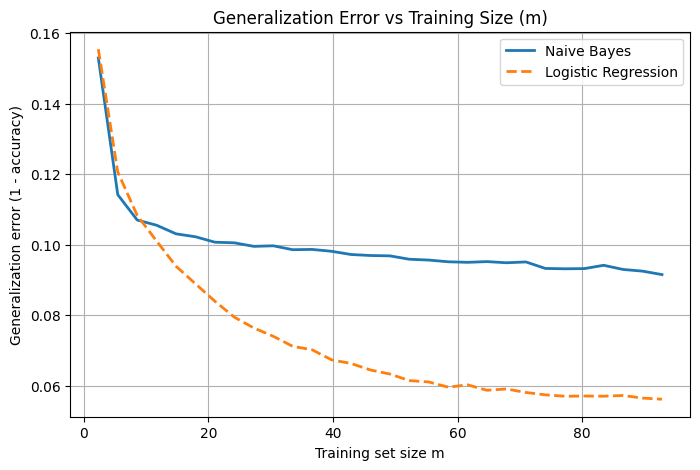

In [50]:
plot_learning_curves(m_values, scores_nbc, scores_lr)


In [65]:
df_breast = pd.read_csv("breast-cancer.csv")

n_init = len(df_breast)
# drop NAN values
df_voting = df_breast.dropna()

n_final = len(df_breast)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")

Initial number of rows: 286
Number of rows dropped: 0
Final number of rows: 286


In [55]:
df_breast

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


In [61]:
enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_cancer = enc.fit_transform(df_breast['Class'].to_numpy())

data_dummies = pd.get_dummies(
    df_breast, 
    columns=['menopause', 'breast', 'irradiat', 'breast-quad'])

cols = ['inv-nodes', 'node-caps', 'deg-malig','tumor-size','age']
enc = OrdinalEncoder()
enc.set_output(transform="pandas")

X_ord_df = enc.fit_transform(df_breast[cols])

# Drop original ordinal cols from dummies DF if they are still there
data_dummies = data_dummies.drop(columns=cols)

X_final = pd.concat([data_dummies, X_ord_df], axis=1)

X_final

,Class,menopause_ge40,menopause_lt40,menopause_premeno,breast_left,breast_right,irradiat_no,irradiat_yes,breast-quad_?,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,inv-nodes,node-caps,deg-malig,tumor-size,age
0,no-recurrence-events,False,False,True,True,False,True,False,False,False,True,False,False,False,0.0,1.0,2.0,5.0,1.0
1,no-recurrence-events,False,False,True,False,True,True,False,False,False,False,False,False,True,0.0,1.0,1.0,3.0,2.0
2,no-recurrence-events,False,False,True,True,False,True,False,False,False,True,False,False,False,0.0,1.0,1.0,3.0,2.0
3,no-recurrence-events,True,False,False,False,True,True,False,False,False,False,True,False,False,0.0,1.0,1.0,2.0,4.0
4,no-recurrence-events,False,False,True,False,True,True,False,False,False,False,False,True,False,0.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,False,False,True,True,False,True,False,False,False,False,True,False,False,0.0,1.0,1.0,5.0,1.0
282,recurrence-events,False,False,True,True,False,False,True,False,False,False,True,False,False,0.0,1.0,2.0,3.0,1.0
283,recurrence-events,True,False,False,False,True,True,False,False,False,False,True,False,False,0.0,1.0,0.0,3.0,4.0
284,recurrence-events,True,False,False,True,False,True,False,False,False,True,False,False,False,4.0,1.0,2.0,5.0,2.0


In [ ]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    X_final,
    'Class',
    runs_per_m=1000
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)

/Users/saitovicjan/Desktop/UZH/2_Semester/Foundations_DS/Practical_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/saitovicjan/Desktop/UZH/2_Semester/Foundations_DS/Practical_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You mi

In [ ]:
plot_learning_curves(m_values, scores_nbc, scores_lr)